# EECE 5644: Introduction to Machine Learning

## Assignment 04 · Titanic Survival Prediction using Decision Trees

## 1. Load and Inspect the Data

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import tree
from sklearn.tree import plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load the dataset
df = pd.read_csv('titanic.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (891, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Prepare the Features

In [98]:
inputs = df[['Pclass', 'Sex', 'Age', 'Fare']].copy()
target = df['Survived']

le_sex = LabelEncoder()
inputs['Sex_n'] = le_sex.fit_transform(inputs['Sex'])

inputs_n = inputs.drop('Sex', axis='columns')

inputs_n['Age'] = inputs_n['Age'].fillna(inputs_n['Age'].median())

print("Predictors shape:", inputs_n.shape)
print("\nProcessed features (inputs_n):")
inputs_n.head()

Predictors shape: (891, 4)

Processed features (inputs_n):


,Pclass,Age,Fare,Sex_n
0,3,22.0,7.2500,1
1,1,38.0,71.2833,0
2,3,26.0,7.9250,0
3,1,35.0,53.1000,0
4,3,35.0,8.0500,1


## 3. Split the Data

In [99]:
X_train, X_test, y_train, y_test = train_test_split(inputs_n, target, test_size=0.2, random_state=42)
model = tree.DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

## 5. Evaluate the Model

In [100]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f"Train Accuracy: {train_score:.4f}")
print(f"Test Accuracy: {test_score:.4f}\n")

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did Not Survive', 'Survived'])

Train Accuracy: 0.8272
Test Accuracy: 0.7989

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



## 6. Model Interpretation: Feature Importance and Tree Plot

Feature Importances:
Sex_n     0.623887
Pclass    0.235428
Age       0.077610
Fare      0.063075
dtype: float64


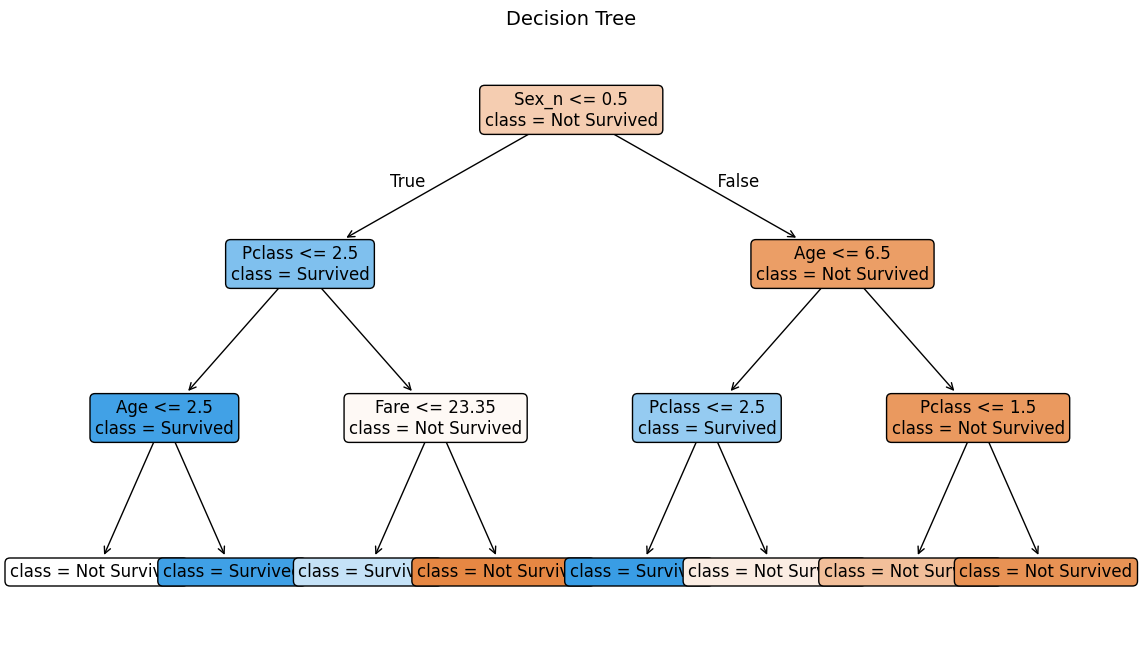

In [101]:
importances = pd.Series(model.feature_importances_, index=inputs_n.columns).sort_values(ascending=False)
print("Feature Importances:")
print(importances)

plt.figure(figsize=(14, 8))
annotations = plot_tree(model, feature_names=inputs_n.columns.tolist(), class_names=['Not Survived', 'Survived'], filled=True, rounded=True, fontsize=12)
for ann in annotations:
    lines = ann.get_text().split('\n')
    filtered_lines = [line for line in lines if not (line.startswith('gini') or line.startswith('samples') or line.startswith('value'))]
    ann.set_text('\n'.join(filtered_lines))
plt.title("Decision Tree", fontsize=14)
plt.show()

## 7. Make Predictions for Custom Passengers

In [102]:
custom_passengers = pd.DataFrame([
    [1, 25.0, 100.0, 0],
    [3, 30.0, 8.0, 1]   
], columns=inputs_n.columns.tolist())

predictions = model.predict(custom_passengers)
probabilities = model.predict_proba(custom_passengers)

for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    status = "Survived" if pred == 1 else "Did Not Survive"
    print(f"Passenger {chr(65+i)}: Predicted Status = {status} | Survival Probability = {prob[1]:.4f}")

Passenger A: Predicted Status = Survived | Survival Probability = 0.9688
Passenger B: Predicted Status = Did Not Survive | Survival Probability = 0.1186
